In [1]:
# reload modules before execution (for the changing code in Src)
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import sqlite3
# uses the DB created in https://github.com/reebme/curated-data-sqlite
from config import DB_PATH

# uses functions from https://github.com/reebme/curated-data-sqlite
# from src/utils.py
CURATED_DATA = Path("../../Curated_Data_SQLite").resolve()
sys.path.append(str(CURATED_DATA / "src"))
import utils

import pandas as pd
import numpy as np
from itertools import combinations, product

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

from scipy.stats import norm, beta, pearsonr

from scipy.special import gamma

In [3]:
sql_folder = "../Sql/"
pic_folder = Path("../../Medium_Articles/spurious_correlations/spurious_corr_expl_pic").resolve()

In [4]:
def compute_cube_limit(points, pad=0.1):
    """
    Half-width of a symmetric plotting cube containing the points.
    """
    return np.round((1 + pad) * np.max(np.abs(points)))

In [5]:
def plot_plane_in_cube(
    ax,
    normal=(1, 1, 1),
    offset=0,
    lim=4,
    alpha=0.05,
    color=None,
    linewidth=0,
):
    """
    Plot the part of the plane

        normal[0] * x + normal[1] * y + normal[2] * z = offset

    inside the cube [-lim, lim]^3.
    """

    normal = np.asarray(normal, dtype=float)

    if np.allclose(normal, 0):
        raise ValueError("normal vector cannot be zero")

    vertices = []

    # Intersections with cube edges:
    # Fix two coordinates at cube boundaries, solve for the third.
    for i, j in combinations(range(3), 2):
        k = ({0, 1, 2} - {i, j}).pop()

        if np.isclose(normal[k], 0):
            continue

        for a, b in product([-lim, lim], repeat=2):
            p = np.zeros(3)
            p[i] = a
            p[j] = b
            p[k] = (offset - normal[i] * a - normal[j] * b) / normal[k]

            if -lim <= p[k] <= lim:
                vertices.append(p)

    if len(vertices) < 3:
        return None

    vertices = np.unique(np.round(vertices, 12), axis=0)

    if len(vertices) < 3:
        return None

    # Order vertices around their center
    center = vertices.mean(axis=0)

    # Build an orthonormal basis inside the plane
    # Pick a vector not parallel to the normal
    candidate = np.array([1.0, 0.0, 0.0])
    if np.allclose(np.cross(normal, candidate), 0):
        candidate = np.array([0.0, 1.0, 0.0])

    u = np.cross(normal, candidate)
    u = u / np.linalg.norm(u)

    v = np.cross(normal, u)
    v = v / np.linalg.norm(v)

    coords = np.column_stack([
        (vertices - center) @ u,
        (vertices - center) @ v
    ])

    angles = np.arctan2(coords[:, 1], coords[:, 0])
    vertices = vertices[np.argsort(angles)]

    return ax.plot_trisurf(
        vertices[:, 0],
        vertices[:, 1],
        vertices[:, 2],
        alpha=alpha,
        color=color,
        linewidth=linewidth,
    )

In [6]:
def add_3d_shadows(
    ax,
    x,
    y,
    z,
    lim,
    s=5,
    alpha=0.05,
    color="lightgrey",
):
    """
    Add projected shadows of a 3D point cloud onto the three cube walls.
    Assumes axes limits are [-lim, lim] in all directions.
    """

    xmin, xmax = -lim, lim
    ymin, ymax = -lim, lim
    zmin, zmax = -lim, lim

    # xy projection, onto bottom z-wall
    ax.scatter(x, y, zs=zmin, zdir="z", s=s, alpha=alpha, color=color)

    # xz projection, onto back y-wall
    ax.scatter(x, z, zs=ymax, zdir="y", s=s, alpha=alpha, color=color)

    # yz projection, onto left x-wall
    ax.scatter(y, z, zs=xmin, zdir="x", s=s, alpha=alpha, color=color)

In [7]:
def pretty_3d_axes(ax, lim, n_ticks=5):
    """
    Make a matplotlib 3D axis pretty
    """

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)

    ticks = np.linspace(-lim, lim, n_ticks)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)

    ax.xaxis.label.set_color("0.4")
    ax.yaxis.label.set_color("0.4")
    ax.zaxis.label.set_color("0.4")

    ax.xaxis.pane.set_alpha(0.1)
    ax.yaxis.pane.set_alpha(0.1)
    ax.zaxis.pane.set_alpha(0.1)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]["color"] = (0.8, 0.8, 0.8, 0.25)
        axis.line.set_color((0.8, 0.8, 0.8, 0.3))

    ax.tick_params(colors="0.7")
    ax.set_box_aspect([1, 1, 1])

In [8]:
def pretty_3Dscatter_points(points,
                            pad = 0.1,
                            scatter_color='#6376bb',
                            hyperplane=None,
                            add_shadows = False,
                            azim=-30,
                            save_file=None):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection="3d")
    
    lim = compute_cube_limit(points, pad)
    
    x = points[0, :]
    y = points[1, :]
    z = points[2, :]
    
    # the main 3D cloud
    ax.scatter(x, y, z, s=2, alpha=0.4, color = scatter_color)

    if hyperplane is not None:
        # the hyperplane they are on
        plot_plane_in_cube(
            ax,
            normal=hyperplane,
            offset=0,
            lim=lim,
            alpha=0.05
        )

    if add_shadows:
        add_3d_shadows(ax, x, y, z, lim, s = 2)
    
    ax.set_xlabel("coordinate 1", fontsize=14)
    ax.set_ylabel("coordinate 2", fontsize=14)
    ax.set_zlabel("coordinate 3", fontsize=14)
    
    pretty_3d_axes(ax, lim)
    
    ax.view_init(elev=10, azim=azim)

    if save_file:
        plt.savefig(save_file,
                dpi=300,
                bbox_inches="tight")
        
    plt.show()

In [9]:
scatter_color = '#6376bb'

In [10]:
rng = np.random.default_rng()

# The experiment, multivariate normal n = 3 (visualization of the transformations)

In [11]:
# no of dimensions
d = 3000
# no of data points
n = 3

# n x d feature matrix
X = rng.standard_normal((n, d))

## Centering the vectors
Pearson's correlation is invariant under affine transformations (up to a sign) and fully invariant under Z-score transformations. Therefore, without loss of generality, we consider vectors sampled from the standard multivariate normal distribution:
$$
X_j \sim \mathcal N_n(0,I_n), \qquad j=1,\ldots,d.
$$

The centering below is not a preprocessing step. It is the centering that appears in the definition of Pearson's correlation.

For the j-th vector, the sample mean is:
$$ \overline{X_j} = \frac{1}{n}\sum_{i=1}^n X_{ij} $$

and sample means form a row vector:
$$
\overline{X} = \left[\overline{X_1}, \dots, \overline{X_d}\right]
$$

Then centering gives:
$$ 
\widetilde{X} = X - \mathbb{1}_n\overline{X}
$$

where n x 1

$$
\mathbf{1}_n =
\begin{bmatrix}
1 \\
\vdots \\
1 \\
\end{bmatrix}
$$

We know that sum of coordinates of a centered vector is 0:
$$
\forall j = 1\dots d: \ \sum_{i=1}^{n}\widetilde{X_{ij}}=0
$$

so every centered vector lies in the hyperplane

$$
H=\left\{z\in\mathbb{R}^n:\sum_{i=1}^{n}z_i=0\right\}
$$


In [12]:
# centering vectors required by the Pearson's correlation
tilde_X = X - X.mean(axis = 0, keepdims = True)

### Visualization of the transformation in the original coordinate system

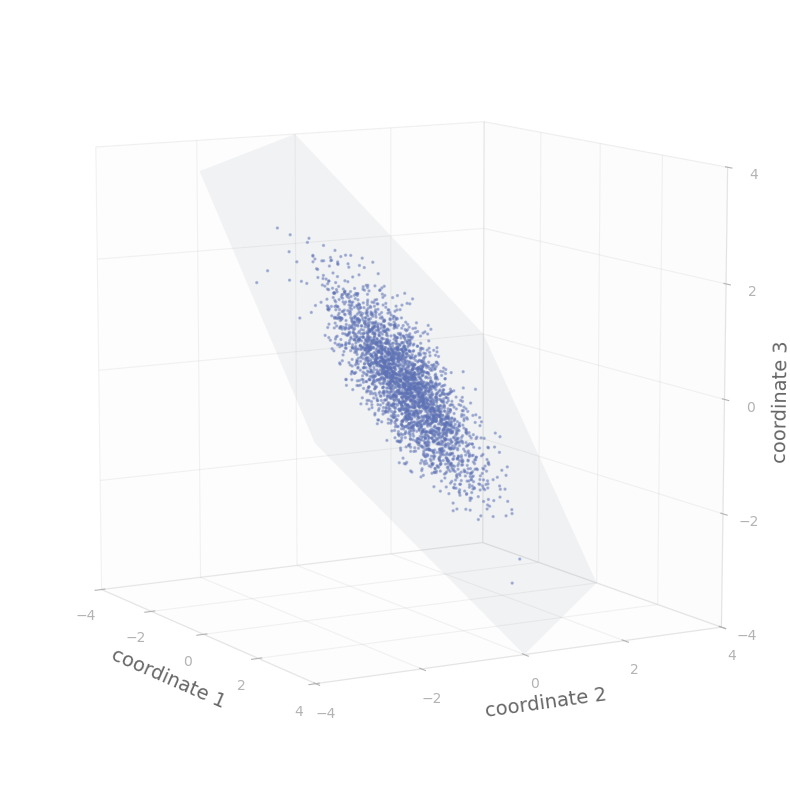

In [13]:
pretty_3Dscatter_points(tilde_X, hyperplane=np.ones(n))

In [14]:
# all centered vectors are orthogonal to the vector of ones
# and thus on the plane orthogonal to the vector of ones
np.allclose(np.ones(n) @ tilde_X, 0)

True

We know centered vectors are in the (n-1)-dim subspace, on a hyperplane orthogonal to the vector of ones.

PCA finds the sequence of orthogonal directions that capture as much variance as possible. Thus PCA finds an orthonormal basis

$$
v_1\dots v_n
$$

ordered by decreasing explained variance:

$$
\lambda_1\geq \dots \geq \lambda_n
$$

The eigendecomposition appears because the variance-maximization problem has eigenvectors as its solutions.

Since centering imposes a linear constraint:

$$
\forall j = 1\dots d: \ \mathbb{1}_n^T \ \widetilde{X_{\cdot j}} = 0
$$

all centered vectors lie in an (n−1)-dimensional subspace. Consequently, the covariance matrix has rank at most n−1, and one eigenvalue is exactly zero. Corresponding eigenvector is:

$$
v_n \propto \mathbb{1}_n
$$

(they have the same direction).

The orthonormal basis found by PCA provides a convenient coordinate system for representing and visualizing the vectors in the (n−1)-dimensional subspace. Since PCA only rotates the coordinate system, representing the data using all n−1 nonzero principal components preserves all variance.

In [15]:
pca = PCA()

hyperplane_points = pca.fit_transform(tilde_X.T)

print(np.round(pca.explained_variance_, 4))
print(np.sum(pca.explained_variance_))
print(np.round(pca.explained_variance_ratio_, 4))

[1.0234 0.9647 0.    ]
1.9880775787741678
[0.5148 0.4852 0.    ]


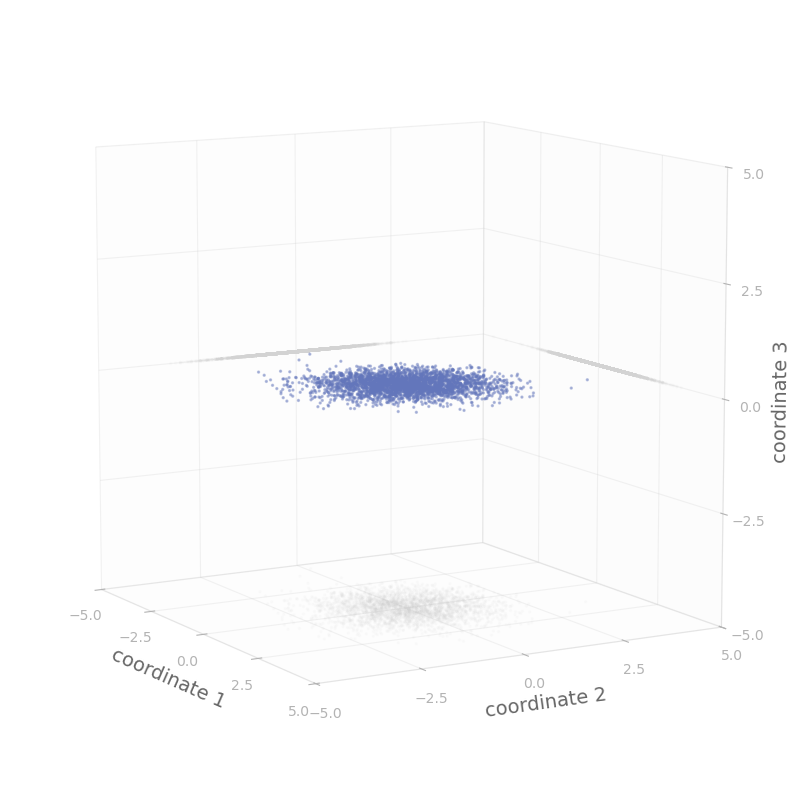

In [16]:
pretty_3Dscatter_points(hyperplane_points.T, add_shadows=True)

## Normalizing the vectors

In [17]:
U = tilde_X / np.linalg.norm(tilde_X, axis = 0, keepdims=True)

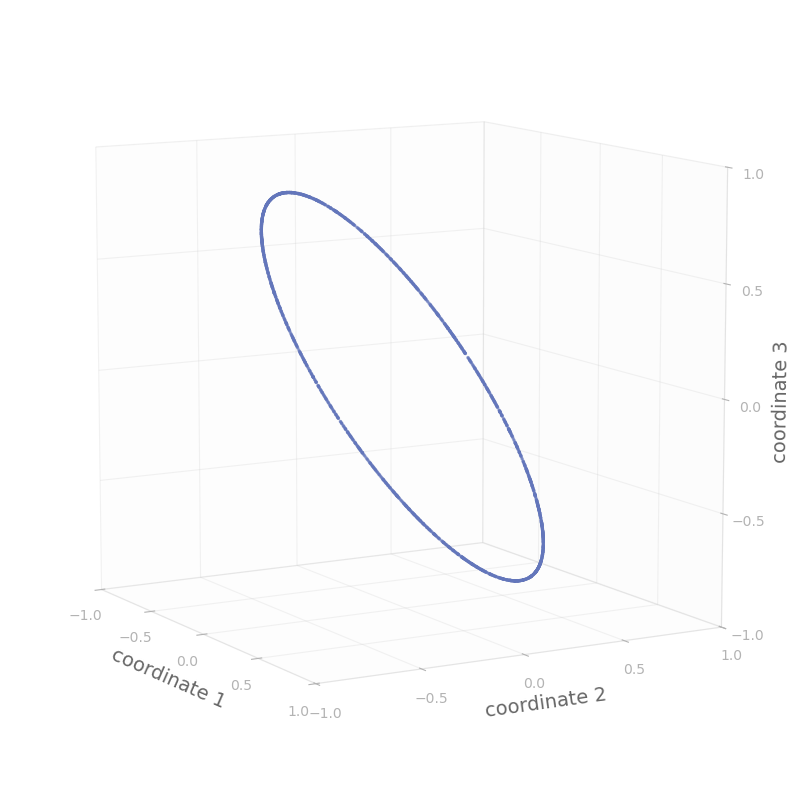

In [18]:
pretty_3Dscatter_points(U)

In [19]:
norm_coords = pca.fit_transform(U.T)
print(np.round(pca.explained_variance_, 4))
print(np.sum(pca.explained_variance_))
print(np.round(pca.explained_variance_ratio_, 4))

[0.5197 0.4806 0.    ]
1.0002812216389247
[0.5195 0.4805 0.    ]


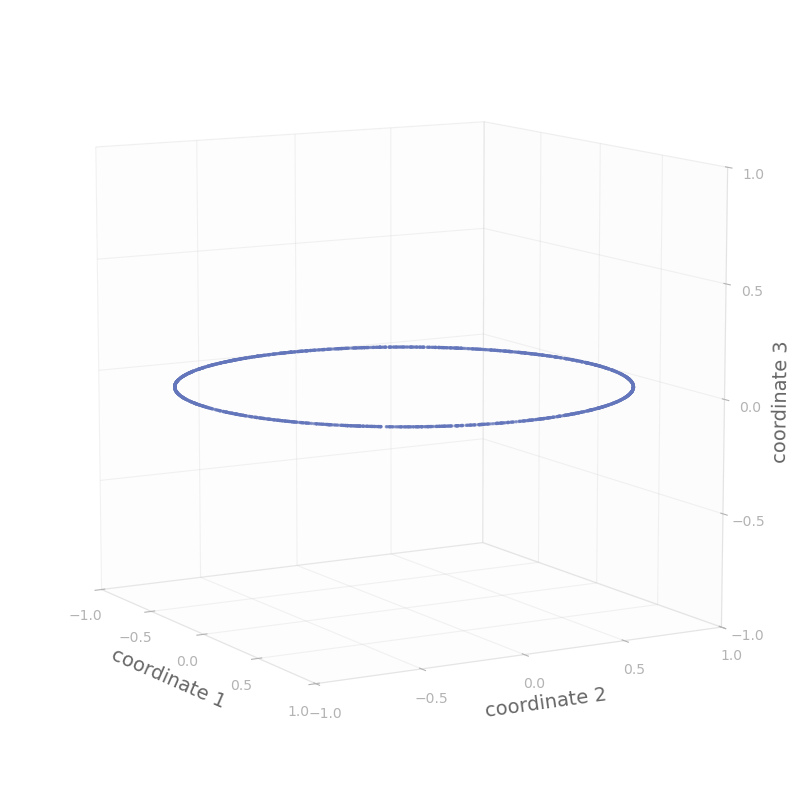

In [20]:
pretty_3Dscatter_points(norm_coords.T)

# The experiment

In [11]:
norm_color = '#473356'
norm_label = "$N\\left(0, \\frac{1}{n-1}\\right)$"

sample_color = '#a5c4b6'

exact_color = 'fuchsia'
exact_label = "Exact distribution\nunder the null"

In [18]:
# no of dimensions
d = 5000
# no of data points
n = 5
assert n > 2

X = rng.standard_normal((n, d))
dist_str = "normal"

# random exponential sample
# (1/scale) * exp{-(1/scale)x}
# X = rng.exponential(scale=5, size=(n, d))
# dist_str = 'exponential'

# X = rng.lognormal(mean=0, sigma=1, size=(n, d))
# dist_str = 'lognormal'

# X = rng.chisquare(df=5, size=(n, d))
# dist_str = 'chi squared'

# symmetric distributions

# X = rng.laplace(loc=0, scale=1, size=(n, d))
# dist_str = 'laplace'

# X = rng.uniform(low=-3, high=1, size=(n, d))
# dist_str = 'uniform'

# U shaped symmetrical distribution
# Z = rng.beta(a=0.2, b=0.2, size=(n, d))
# X = 2 * Z - 1
# dist_str = 'U shaped'

# X = rng.standard_cauchy((n, d))
# dist_str = 'cauchy'

# centering
tilde_X = X - X.mean(axis = 0, keepdims = True)

# normalization
U = tilde_X/np.linalg.norm(tilde_X, axis = 0, keepdims = True)

# correlation matrix
R = U.T @ U
assert (np.round(R, 6) == np.round(U.T @ U, 6)).sum() == d**2

# flatten the correlations
corrs = R[np.eye(d) != 1].ravel()

In [19]:
print(f"1 SD for correlations under the independent Gaussian null: {1/np.sqrt(n - 1)}\n")

# empirical distribution
q025, q975 = np.quantile(corrs, [0.025, 0.975])
print(f"95% of empirical sample distribution mass lives inside: [{q025:.4f}, {q975:.4f}] with midpoint at {(q025 + q975)/2:.4f}")
print(f"P(X < {q025}) = {(corrs < q025).mean()}")
print(f"P(X > {q975}) = {(corrs > q975).mean()}")
print(f"P(X < {q025} or X > {q975}) = {(corrs < q025).mean() + (corrs > q975).mean()}\n")

# asymptotic normal distribution
norm_distr = norm(loc=0, scale=1/np.sqrt(n-1))
q025_norm, q975_norm = norm_distr.ppf([0.025, 0.975])
print(f"95% of asymptotic normal distribution mass lives inside: [{q025_norm:.4f}, {q975_norm:.4f}]")
print(f"P(X < {q025_norm}) = {(corrs < q025_norm).mean()}")
print(f"P(X > {q975_norm}) = {(corrs > q975_norm).mean()}")
print(f"P(X < {q025_norm} or X > {q975_norm}) = {(corrs < q025_norm).mean() + (corrs > q975_norm).mean()}\n")

# exact distribution under independent Gaussian null
a = 1/2
b = (n - 2)/2
q975_exact = np.sqrt(beta.ppf(1 - 0.05, a, b))
q025_exact = -q975_exact
print(f"95% of exact distribution under the Gaussian null mass lives inside: [{q025_exact:.4f}, {q975_exact:.4f}]")
print(f"P(X < {q025_exact}) = {(corrs < q025_exact).mean()}")
print(f"P(X > {q975_exact}) = {(corrs > q975_exact).mean()}")
print(f"P(X < {q025_exact} or X > {q975_exact}) = {(corrs < q025_exact).mean() + (corrs > q975_exact).mean()}\n")

1 SD for correlations under the independent Gaussian null: 0.5

95% of empirical sample distribution mass lives inside: [-0.8784, 0.8786] with midpoint at 0.0001
P(X < -0.8783557237424164) = 0.0249999599919984
P(X > 0.8786147825058688) = 0.0249999599919984
P(X < -0.8783557237424164 or X > 0.8786147825058688) = 0.0499999199839968

95% of asymptotic normal distribution mass lives inside: [-0.9800, 0.9800]
P(X < -0.9799819922700272) = 0.0016994598919783956
P(X > 0.979981992270027) = 0.0017047409481896379
P(X < -0.9799819922700272 or X > 0.979981992270027) = 0.0034042008401680337

95% of exact distribution under the Gaussian null mass lives inside: [-0.8783, 0.8783]
P(X < -0.8783394481598051) = 0.02500460092018404
P(X > 0.8783394481598051) = 0.02508149629925985
P(X < -0.8783394481598051 or X > 0.8783394481598051) = 0.05008609721944389



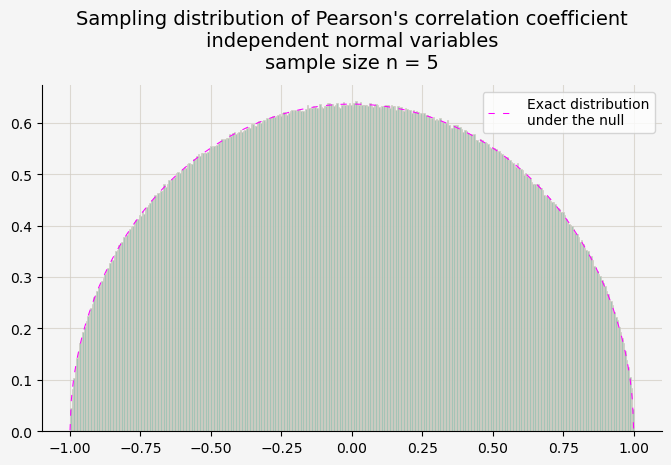

In [20]:
# visualizations
if n < 5:
    # centered vectors, original coords
    if n == 3:
        hyperplane = np.ones(3)
    else: hyperplane = None
    filename = pic_folder / f"centered_vectors_orig_coords_{dist_str}_{n}D.png"
    pretty_3Dscatter_points(tilde_X,
                            hyperplane=hyperplane,
                            save_file = filename)

    # centered vectors, orthonormal basis allowing for reduction ov variability in n-th coord
    pca = PCA()
    hyperplane_points = pca.fit_transform(tilde_X.T)
    #print(np.round(pca.explained_variance_, 4))
    #print(np.sum(pca.explained_variance_))
    #print(np.round(pca.explained_variance_ratio_, 4))

    if n == 3:
        add_shadows = True
    else: add_shadows = False
    filename = pic_folder / f"centered_vectors_PCA_coords_{dist_str}_{n}D.png"
    pretty_3Dscatter_points(hyperplane_points.T,
                            add_shadows=add_shadows, 
                            save_file = filename)

    # normalized vectors, original coords
    if n == 4:
        # 3d sphere is an ellipsoid in 4D when any 3 coords are taken
        add_shadows = True
    else: add_shadows = False
    filename = pic_folder / f"normalized_vectors_orig_coords_{dist_str}_{n}D.png"
    pretty_3Dscatter_points(U, 
                            add_shadows=add_shadows, 
                            save_file = filename)

    # normalized vectors, n-1 subspace
    norm_coords = pca.fit_transform(U.T)
    #print(np.round(pca.explained_variance_, 4))
    #print(np.sum(pca.explained_variance_))
    #print(np.round(pca.explained_variance_ratio_, 4))
    filename = pic_folder / f"normalized_vectors_PCA_coords_{dist_str}_{n}D.png"
    pretty_3Dscatter_points(norm_coords.T,
                            pad = 1, 
                            save_file = filename)

#vertical_lines = [(q025, sample_color), (q975, sample_color)]
#vertical_lines.append((q025_norm, norm_color))
#vertical_lines.append((q975_norm, norm_color))

vertical_lines = [(-0.4, exact_color), (0.4, exact_color)]

pdf_to_plot_norm = lambda x: norm_distr.pdf(x)
pdf_to_plot_exact_pearson = lambda x: gamma((n-1)/2)/(np.sqrt(np.pi)*gamma((n-2)/2))*(1-x**2)**((n-4)/2)

title = (
    "Sampling distribution of Pearson's correlation coefficient\n"
    f"independent {dist_str} variables\n"
    f"sample size n = {n}"
)

#if n == 3:
    # the exact distribution blows up at the edges
#    density_fn = [(pdf_to_plot_norm, norm_color, norm_label, "-")]
#else:
#density_fn = [(pdf_to_plot_exact_pearson, exact_color, exact_label, (0, (6, 8))), (pdf_to_plot_norm, norm_color, norm_label, "-")]
density_fn = [((pdf_to_plot_exact_pearson, exact_color, exact_label, (0, (6, 8))))]

filename = pic_folder / f"correlations_{dist_str}_{n}D.png"
    
utils.pretty_histogram(corrs,
                       title=title,
                       # vertical_lines=vertical_lines,
                       density = True,
                       density_fn = density_fn,
                       save_file_name=filename)